In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split

In [17]:
# def load_dataset(data_dir, test_size=0.2, val_size=0.2, random_state=42):
#     """Load dataset from directory structure"""
    
#     classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
#     class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
#     image_paths = []
#     labels = []
    
#     print(f"Loading dataset from {data_dir}")
#     print(f"Found {len(classes)} classes: {classes}")
    
#     for class_name in classes:
#         class_dir = os.path.join(data_dir, class_name)
#         class_idx = class_to_idx[class_name]
        
#         for img_name in os.listdir(class_dir):
#             if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.HEIC')):
#                 img_path = os.path.join(class_dir, img_name)
#                 image_paths.append(img_path)
#                 labels.append(class_idx)
    
#     print(f"Total images: {len(image_paths)}")
    
#     # Split into train, validation, and test sets
#     X_temp, X_test, y_temp, y_test = train_test_split(
#         image_paths, labels, test_size=test_size, random_state=random_state, stratify=labels
#     )
    
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
#     )
    
#     print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")
    
#     return (X_train, y_train), (X_val, y_val), (X_test, y_test), classes

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from PIL import Image
import pillow_heif  # You'll need to install this: pip install pillow-heif

# Register HEIF opener with Pillow
pillow_heif.register_heif_opener()

def load_dataset(data_dir, test_size=0.2, val_size=0.2, random_state=42):
    """Load dataset from directory structure with HEIC support"""
    
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    image_paths = []
    labels = []
    
    print(f"Loading dataset from {data_dir}")
    print(f"Found {len(classes)} classes: {classes}")
    
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        class_idx = class_to_idx[class_name]
        
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
                img_path = os.path.join(class_dir, img_name)
                image_paths.append(img_path)
                labels.append(class_idx)
    
    print(f"Total images: {len(image_paths)}")
    
    # Split into train, validation, and test sets
    X_temp, X_test, y_temp, y_test = train_test_split(
        image_paths, labels, test_size=test_size, random_state=random_state, stratify=labels
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
    )
    
    print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), classes

# And here's the rotation code that will work with HEIC files:
def show_original_and_rotated(image_path):
    """Display original and 90-degree rotated image side by side"""
    # Load the image (works with HEIC now)
    img = Image.open(image_path)
    
    # Rotate the image by 90 degrees
    rotated_img = img.rotate(90, expand=True)
    
    # Display both images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(rotated_img)
    axes[1].set_title('Rotated 90°')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# show_original_and_rotated('path/to/your/leaf.heic')

In [7]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), classes = load_dataset("/Users/abdulmateen/Downloads/veggie",)

Loading dataset from /Users/abdulmateen/Downloads/veggie
Found 10 classes: ['Bitterleaf', 'Efirin', 'Ewedu', 'amunututu', 'elegede', 'soko ', 'tete ', 'ugu ', 'uziza leave', 'waterleaf']
Total images: 1853
Train: 1185, Validation: 297, Test: 371


Random images from dataset:


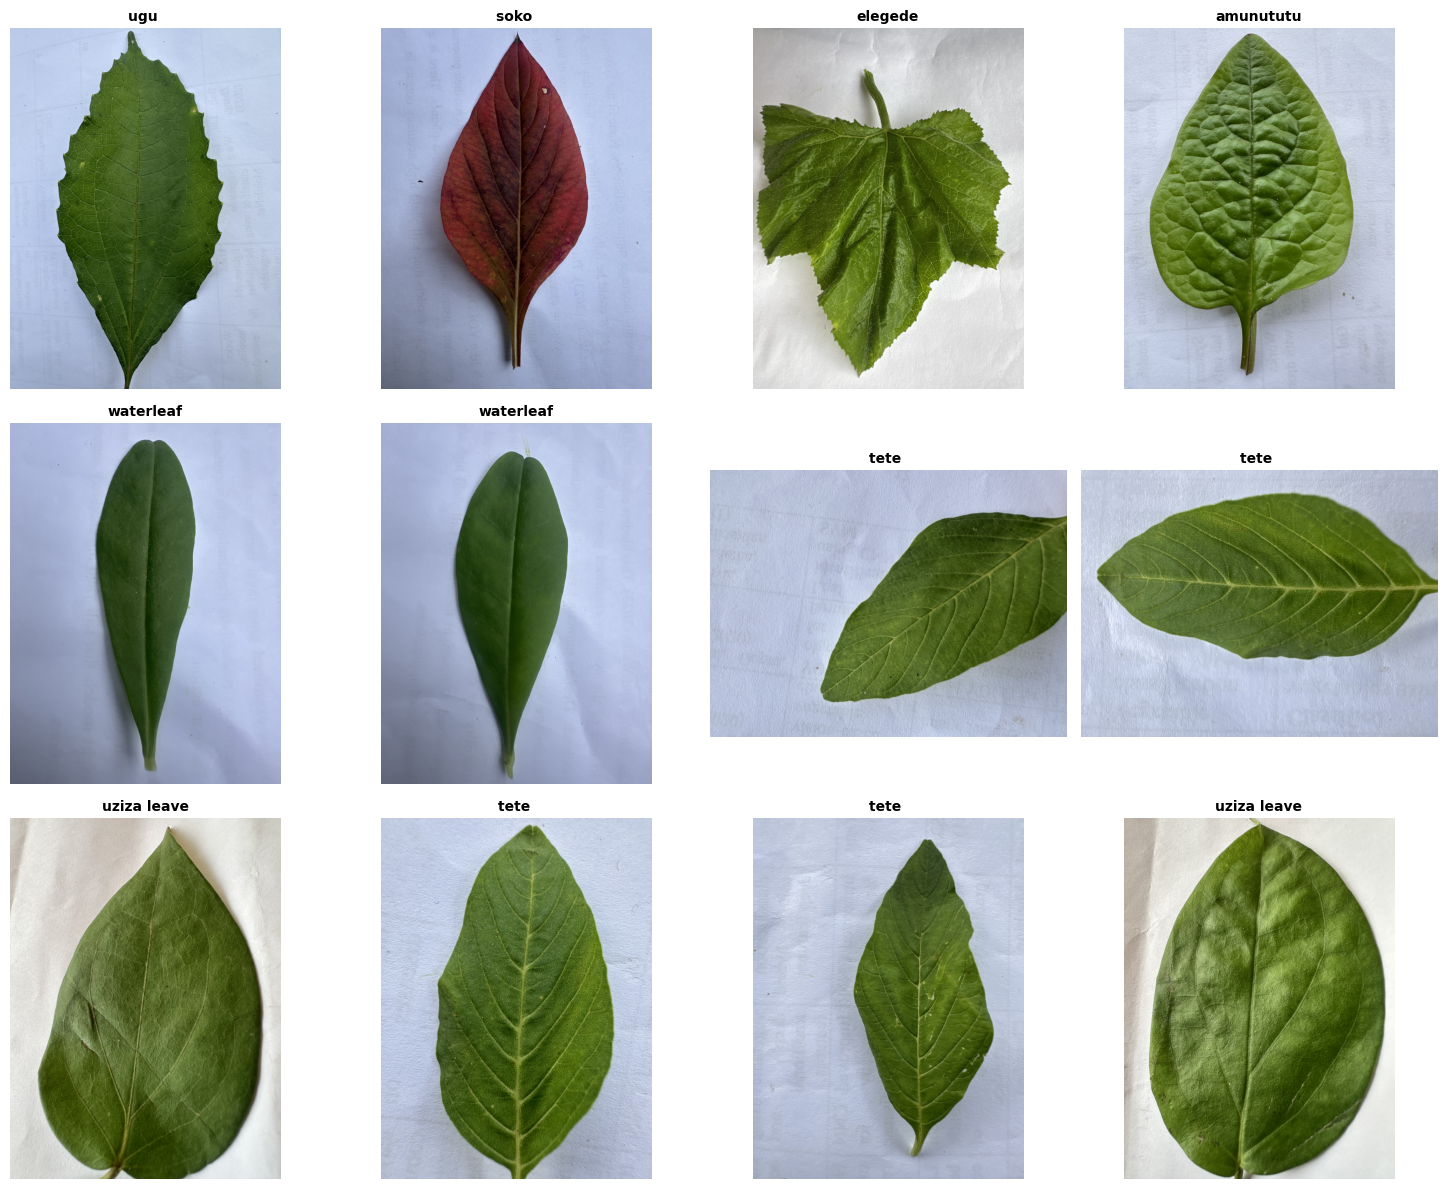

Images organized by class:


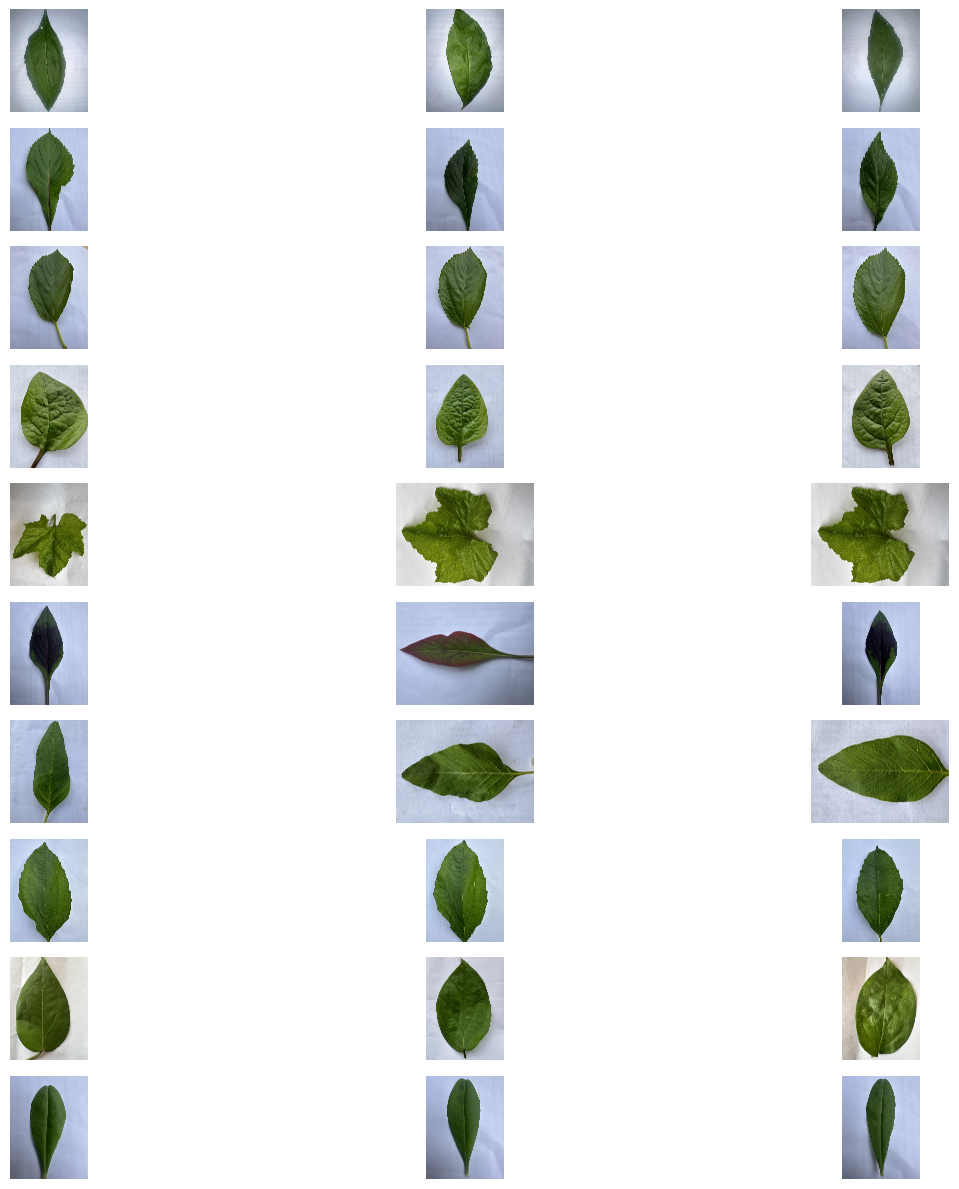

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

def view_images_with_labels(image_paths, labels, class_names, num_images=12, figsize=(15, 12)):
    """
    Display a grid of images with their class labels
    """
    # Randomly sample images if we have more than num_images
    if len(image_paths) > num_images:
        indices = random.sample(range(len(image_paths)), num_images)
    else:
        indices = list(range(len(image_paths)))
    
    # Calculate grid dimensions
    cols = 4
    rows = (num_images + cols - 1) // cols
    
    # Create figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
            
        # Load and display image
        img_path = image_paths[idx]
        label_idx = labels[idx]
        class_name = class_names[label_idx]
        
        try:
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f'{class_name}', fontsize=10, fontweight='bold')
            axes[i].axis('off')
        except Exception:
            axes[i].text(0.5, 0.5, f'Error loading\n{os.path.basename(img_path)}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{class_name}', fontsize=10, fontweight='bold')
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(len(indices), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def view_images_by_class(image_paths, labels, class_names, images_per_class=3, figsize=(15, 12)):
    """
    Display images organized by class
    """
    num_classes = len(class_names)
    cols = images_per_class
    rows = num_classes
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for class_idx, class_name in enumerate(class_names):
        # Find images for this class
        class_indices = [i for i, label in enumerate(labels) if label == class_idx]
        
        # Sample images for this class
        if len(class_indices) > images_per_class:
            selected_indices = random.sample(class_indices, images_per_class)
        else:
            selected_indices = class_indices
        
        for col, idx in enumerate(selected_indices):
            plot_idx = class_idx * cols + col
            if plot_idx < len(axes):
                img_path = image_paths[idx]
                
                try:
                    img = mpimg.imread(img_path)
                    axes[plot_idx].imshow(img)
                    if col == 0:  # Only show class name for first image in row
                        axes[plot_idx].set_ylabel(class_name, fontsize=12, fontweight='bold', 
                                                rotation=0, ha='right', va='center')
                    axes[plot_idx].axis('off')
                except Exception:
                    axes[plot_idx].text(0.5, 0.5, f'Error loading\n{os.path.basename(img_path)}', 
                                      ha='center', va='center', transform=axes[plot_idx].transAxes)
                    if col == 0:
                        axes[plot_idx].set_ylabel(class_name, fontsize=12, fontweight='bold', 
                                                rotation=0, ha='right', va='center')
                    axes[plot_idx].axis('off')
    
    # Hide unused subplots
    for i in range(num_classes * cols, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage examples (assuming you have already loaded your dataset):
# (X_train, y_train), (X_val, y_val), (X_test, y_test), classes = load_dataset(data_dir)

# View random images with labels
print("Random images from dataset:")
view_images_with_labels(X_train, y_train, classes, num_images=12)

# View images organized by class
print("Images organized by class:")
view_images_by_class(X_train, y_train, classes, images_per_class=3)

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [8]:
import os
import tensorflow as tf
import numpy as np
import pillow_heif

# Register HEIF opener with Pillow
pillow_heif.register_heif_opener()

# === Main dataset folder ===
dataset_path = "/Users/abdulmateen/Downloads/veggie"
target_size = (224, 224)

images = []
labels = []
class_names = []

# Map folder names to integer labels
label_map = {}
label_counter = 0

# Loop through each subfolder
for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)
    
    if os.path.isdir(folder_path):
        print(f"Loading class '{folder}' as label {label_counter}")
        label_map[folder] = label_counter
        class_names.append(folder)
        
        for filename in os.listdir(folder_path):
            # Updated to include HEIC files (case-insensitive)
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.heic')):
                img_path = os.path.join(folder_path, filename)
                try:
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
                    img_array = tf.keras.preprocessing.image.img_to_array(img)
                    images.append(img_array)
                    labels.append(label_counter)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
        
        label_counter += 1

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Loaded", len(images), "images from", len(label_map), "classes.")
print("Classes:", label_map)

Loading class 'Bitterleaf' as label 0
Loading class 'Efirin' as label 1
Loading class 'Ewedu' as label 2
Loading class 'amunututu' as label 3
Loading class 'elegede' as label 4
Loading class 'soko ' as label 5
Loading class 'tete ' as label 6
Loading class 'ugu ' as label 7
Loading class 'uziza leave' as label 8
Loading class 'waterleaf' as label 9
Loaded 1853 images from 10 classes.
Classes: {'Bitterleaf': 0, 'Efirin': 1, 'Ewedu': 2, 'amunututu': 3, 'elegede': 4, 'soko ': 5, 'tete ': 6, 'ugu ': 7, 'uziza leave': 8, 'waterleaf': 9}


In [9]:
import os
import tensorflow as tf
import numpy as np

# === Main dataset folder ===
dataset_path = "/Users/abdulmateen/Downloads/tomato"
target_size = (224, 224)

images = []
labels = []
class_names = []

label_map = {}
label_counter = 0

# Sort and limit to first 3 folders
all_folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])
selected_folders = all_folders[:3]  # Only first 3

for folder in selected_folders:
    folder_path = os.path.join(dataset_path, folder)
    print(f"Loading class '{folder}' as label {label_counter}")
    
    label_map[folder] = label_counter
    class_names.append(folder)
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
            img_path = os.path.join(folder_path, filename)
            try:
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                images.append(img_array)
                labels.append(label_counter)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    label_counter += 1

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Loaded", len(images), "images from 3 classes.")
print("Classes used:", label_map)


Loading class 'Bacterial_spot' as label 0
Loading class 'Early_blight' as label 1
Loading class 'Late_blight' as label 2
Loaded 5036 images from 3 classes.
Classes used: {'Bacterial_spot': 0, 'Early_blight': 1, 'Late_blight': 2}


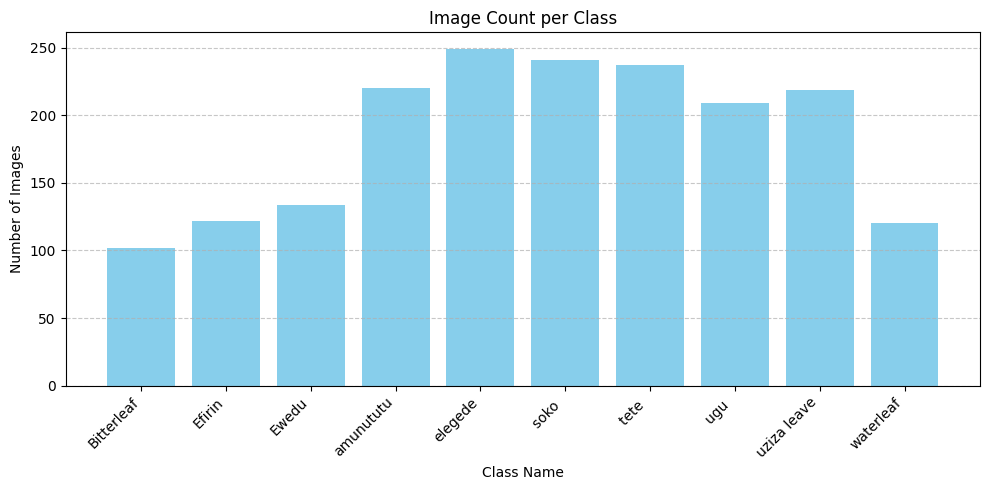

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences of each label
label_counts = Counter(labels)

# Map back to class names
class_labels = [class_names[i] for i in label_counts.keys()]
counts = [label_counts[i] for i in label_counts.keys()]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(class_labels, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Image Count per Class")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [9]:
# images = images / 255.0  # Normalize



# 1. Split into train+val and test (80% train+val, 20% test)
train_val_images, test_images, train_val_labels, test_labels = train_test_split(
    images, labels, test_size=0.1, random_state=42
)

# 2. Split train_val into train and val (e.g., 80% train, 20% val of the 80%)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_val_images, train_val_labels, test_size=0.1, random_state=42
)

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))




Train: 1500
Validation: 167
Test: 186


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
# base_model = tf.keras.applications.MobileNetV2(
#     input_shape=(224, 224, 3),
#     include_top=False,
#     weights='imagenet'
# )
# base_model.trainable = False

# model = keras.Sequential([
#     keras.layers.Input(shape=(224, 224, 3)),
#     keras.layers.Rescaling(1./255),
#     base_model,
#     keras.layers.GlobalAveragePooling2D(),
#     keras.layers.Dropout(0.3),
#     keras.layers.Dense(10, activation='softmax')
# ])
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base model
x = layers.Rescaling(1./255)(inputs)
# Pass input through base model
x = base_model(x, training=False)

# Global pooling and classification
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build model
model = keras.Model(inputs=inputs, outputs=outputs)
# input_shape=(224, 224, 3)
# model = keras.Sequential([
#         keras.layers.Rescaling(1./255, input_shape=input_shape),
#         keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#         keras.layers.MaxPooling2D((2, 2)),
#         keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#         keras.layers.MaxPooling2D((2, 2)),
#         keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#         keras.layers.MaxPooling2D((2, 2)),
#         keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#         keras.layers.Flatten(),
#         keras.layers.Dense(32, activation='relu'),
#         # keras.layers.Dropout(0.5),
#         keras.layers.Dense(10, activation='softmax')  
#     ])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


NameError: name 'x' is not defined

In [20]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# datagen = ImageDataGenerator(
#     rotation_range=20,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     brightness_range=[0.8, 1.2],
#     validation_split=0.2
# )

# train_generator = datagen.flow(
#     train_images, train_labels,
#     subset='training',
#     batch_size=16
# )

# val_generator = datagen.flow(
#     val_images, val_labels,
#     subset='validation',
#     batch_size=16
# )




In [13]:
# Import the callback
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # you can also use 'val_accuracy'
    patience=3,             # number of epochs to wait before stopping
    restore_best_weights=True,  # restores weights from best epoch
    verbose=1
)


In [15]:
history = model.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=8,
    verbose=1,
    # callbacks=[early_stop],
    batch_size=32
)

Epoch 1/8
47/47 [==============================] - 23s 448ms/step - loss: 0.9027 - accuracy: 0.7440 - val_loss: 0.1349 - val_accuracy: 1.0000
Epoch 2/8
47/47 [==============================] - 19s 411ms/step - loss: 0.1064 - accuracy: 0.9927 - val_loss: 0.0424 - val_accuracy: 1.0000
Epoch 3/8
47/47 [==============================] - 17s 355ms/step - loss: 0.0531 - accuracy: 0.9987 - val_loss: 0.0231 - val_accuracy: 1.0000
Epoch 4/8
47/47 [==============================] - 21s 440ms/step - loss: 0.0319 - accuracy: 0.9993 - val_loss: 0.0165 - val_accuracy: 1.0000
Epoch 5/8
47/47 [==============================] - 23s 503ms/step - loss: 0.0243 - accuracy: 0.9993 - val_loss: 0.0113 - val_accuracy: 1.0000
Epoch 6/8
47/47 [==============================] - 29s 615ms/step - loss: 0.0181 - accuracy: 1.0000 - val_loss: 0.0086 - val_accuracy: 1.0000
Epoch 7/8
47/47 [==============================] - 21s 436ms/step - loss: 0.0138 - accuracy: 1.0000 - val_loss: 0.0070 - val_accuracy: 1.0000
Epoch 

In [27]:
import tensorflow as tf
# from tensorflow import keras.optimizers.Adam

In [30]:
# Unfreeze last part of base model
base_model.trainable = True
fine_tune_at = 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=5,
    verbose=1,
    # callbacks=[early_stop],
    batch_size=32
)


Epoch 1/5
47/47 [==============================] - 72s 1s/step - loss: 0.1057 - accuracy: 0.9667 - val_loss: 9.7510 - val_accuracy: 0.4132
Epoch 2/5
47/47 [==============================] - 52s 1s/step - loss: 0.0527 - accuracy: 0.9867 - val_loss: 20.7997 - val_accuracy: 0.1257
Epoch 3/5
47/47 [==============================] - 53s 1s/step - loss: 0.1701 - accuracy: 0.9580 - val_loss: 11.4241 - val_accuracy: 0.5090
Epoch 4/5
47/47 [==============================] - 61s 1s/step - loss: 0.0289 - accuracy: 0.9920 - val_loss: 50.2729 - val_accuracy: 0.2156
Epoch 5/5
47/47 [==============================] - 48s 1s/step - loss: 0.0661 - accuracy: 0.9873 - val_loss: 27.3450 - val_accuracy: 0.2335


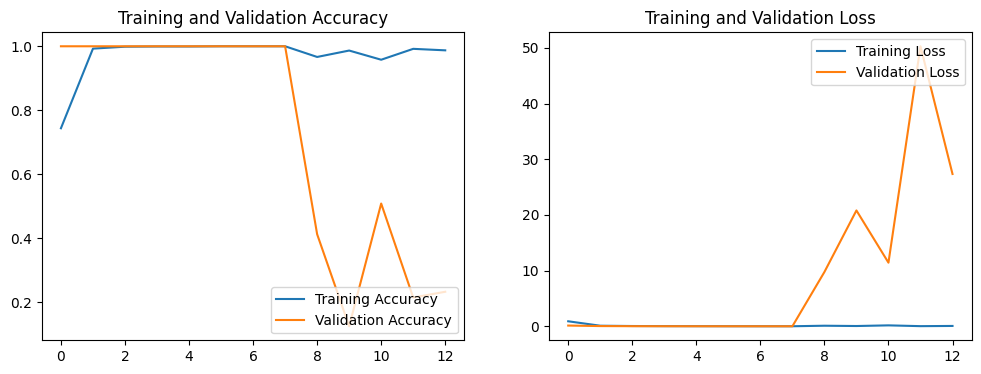

In [31]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [32]:
import tensorflow_model_optimization as tfmot

# Step 1: Quantize the model
quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(model)

# Step 2: Recompile
qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: QAT Fine-tuning (short)
qat_history = qat_model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=3,  # Just a few epochs is enough
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


ValueError: Quantizing a keras Model inside another keras Model is not supported.

In [25]:
model.save('faruq1.h5')

In [22]:
# class_names = {
#     0: "Bacterial_spot",
#     1: "Early_blight",
#     2: "Late_Blight"
# }

# def predict_single_image(model, image_path, target_size=(224, 224)):
#     img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
#     img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     prediction = model.predict(img_array, verbose=0)[0]  # shape: (3,)
#     predicted_class = np.argmax(prediction)
#     confidence = prediction[predicted_class]

#     # Print all probabilities
#     print("\nClass Probabilities:")
#     for i, prob in enumerate(prediction):
#         print(f"{class_names[i]}: {prob:.4f}")

#     return predicted_class, confidence




In [3]:
import os
import tensorflow as tf
import numpy as np
from PIL import Image
import pillow_heif
import matplotlib.pyplot as plt
model = tf.keras.models.load_model('/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/faruq1.h5')
# Register HEIF opener with Pillow
pillow_heif.register_heif_opener()

def predict_single_image(model, image_path, class_names, target_size=(224, 224), show_image=True):
    """
    Make prediction on a single external image
    
    Args:
        model: Your trained Keras model
        image_path: Path to the image file
        class_names: List of class names (same order as training)
        target_size: Input size expected by model (224, 224)
        show_image: Whether to display the image
    
    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score (0-1)
        all_predictions: Array of all class probabilities
    """
    try:
        # Load and preprocess the image
        img = Image.open(image_path)
        
        # Convert to RGB if needed (handles HEIC, PNG with transparency, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Resize to target size
        img = img.resize(target_size)
        
        # Convert to numpy array
        img_array = np.array(img)
        
        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        
        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx]
        predicted_class = class_names[predicted_class_idx]
        
        # Display the image if requested
        if show_image:
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f'Prediction: {predicted_class} (Confidence: {confidence:.2%})')
            plt.axis('off')
            plt.show()
        
        return predicted_class, confidence, predictions[0]
        
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None, None, None

def predict_multiple_images(model, image_folder, class_names, target_size=(224, 224), show_results=True):
    """
    Make predictions on multiple images in a folder
    
    Args:
        model: Your trained Keras model
        image_folder: Path to folder containing images
        class_names: List of class names
        target_size: Input size expected by model
        show_results: Whether to display results
    
    Returns:
        results: List of dictionaries with results for each image
    """
    results = []
    
    # Get all image files in the folder
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.heic')
    image_files = [f for f in os.listdir(image_folder) 
                   if f.lower().endswith(image_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for i, filename in enumerate(image_files):
        image_path = os.path.join(image_folder, filename)
        print(f"\nProcessing {i+1}/{len(image_files)}: {filename}")
        
        predicted_class, confidence, all_predictions = predict_single_image(
            model, image_path, class_names, target_size, show_image=show_results
        )
        
        if predicted_class is not None:
            result = {
                'filename': filename,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'all_predictions': all_predictions
            }
            results.append(result)
            
            print(f"Prediction: {predicted_class} (Confidence: {confidence:.2%})")
        else:
            print(f"Failed to process {filename}")
    
    return results

def show_top_predictions(predictions, class_names, top_n=3):
    """
    Display top N predictions with their probabilities
    
    Args:
        predictions: Array of prediction probabilities
        class_names: List of class names
        top_n: Number of top predictions to show
    """
    # Get indices of top predictions
    top_indices = np.argsort(predictions)[::-1][:top_n]
    
    print(f"\nTop {top_n} predictions:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. {class_names[idx]}: {predictions[idx]:.2%}")

# Example usage functions
def predict_with_your_model(image_path):
    """
    Wrapper function using your specific model and class names
    """
    # Your class names from the training
    class_names = ['Bitterleaf', 'Efirin', 'Ewedu', 'amunututu', 'elegede', 
                   'soko ', 'tete ', 'ugu ', 'uziza leave', 'waterleaf']
    
    # Make prediction
    predicted_class, confidence, all_predictions = predict_single_image(
        model, image_path, class_names, target_size=(224, 224), show_image=True
    )
    
    if predicted_class is not None:
        print(f"\nPredicted class: {predicted_class}")
        print(f"Confidence: {confidence:.2%}")
        
        # Show top 3 predictions
        show_top_predictions(all_predictions, class_names, top_n=3)
    
    return predicted_class, confidence, all_predictions

# Example usage:
predicted_class, confidence, all_predictions = predict_with_your_model('/path/to/your/image.jpg')

# For batch processing:
# results = predict_multiple_images(model, '/path/to/image/folder', class_names)

Error processing image /path/to/your/image.jpg: [Errno 2] No such file or directory: '/path/to/your/image.jpg'


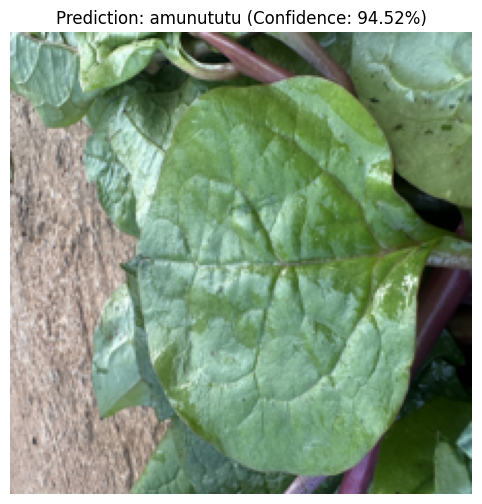


Predicted class: amunututu
Confidence: 94.52%

Top 3 predictions:
1. amunututu: 94.52%
2. tete : 2.51%
3. ugu : 0.79%


In [4]:
predicted_class, confidence, all_predictions = predict_with_your_model('/Users/abdulmateen/Downloads/vegetables/amunututu/IMG_7766.JPG')


In [30]:
# === Usage ===
single_image_path = '/Users/abdulmateen/Downloads/elegede.png'
predicted_class, confidence = predict_single_image(model, single_image_path)
print(f"\nPredicted class: {class_names[predicted_class]} (confidence: {confidence:.3f})")

TypeError: predict_single_image() missing 1 required positional argument: 'class_names'

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# === Your class index-to-name mapping ===
class_names = {
    0: "Bacterial_spot",
    1: "Early_blight",
    2: "Late_Blight"
}

def predict_image_from_path(image_path, model, target_size=(224, 224)):
    """
    Load an image from filepath, preprocess it, and make predictions
    
    Args:
        image_path (str): Path to the image file
        model: Trained model for prediction
        target_size (tuple): Target size for resizing the image (width, height)
    
    Returns:
        tuple: (image_array, prediction_probabilities, predicted_class)
    """
    # Check if file exists
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")
    
    # Load and preprocess the image
    img = Image.open(image_path)
    
    # Convert to RGB if necessary (handles PNG, grayscale, etc.)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Resize image to match model input size
    img = img.resize(target_size)
    
    # Convert to numpy array
    img_array = np.array(img)
    
    # Normalize if your model expects values in [0, 1] range
    # Uncomment the next line if your model was trained with normalized inputs
    # img_array = img_array.astype('float32') / 255.0
    
    # Expand dims for prediction (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)
    
    # Predict
    prediction = model.predict(img_input, verbose=0)[0]
    predicted_class = np.argmax(prediction)
    
    return img_array, prediction, predicted_class

def visualize_prediction(image_path, model, target_size=(224, 224)):
    """
    Predict and visualize a single image from filepath
    
    Args:
        image_path (str): Path to the image file
        model: Trained model for prediction
        target_size (tuple): Target size for resizing the image
    """
    try:
        # Get prediction
        img_array, prediction, predicted_class = predict_image_from_path(
            image_path, model, target_size
        )
        
        # Print probabilities
        print(f"\n🖼️ Image: {os.path.basename(image_path)}")
        print(f"📁 Path: {image_path}")
        for i, prob in enumerate(prediction):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"➡️ Predicted: {class_names[predicted_class]} (confidence: {prediction[predicted_class]:.3f})")
        
        # Display the image
        plt.figure(figsize=(8, 6))
        plt.imshow(img_array.astype("uint8"))
        plt.title(f"Predicted: {class_names[predicted_class]}\nConfidence: {prediction[predicted_class]:.3f}")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing image {image_path}: {str(e)}")

def predict_multiple_images(image_paths, model, target_size=(224, 224)):
    """
    Predict and visualize multiple images from filepaths
    
    Args:
        image_paths (list): List of image file paths
        model: Trained model for prediction
        target_size (tuple): Target size for resizing the image
    """
    for image_path in image_paths:
        visualize_prediction(image_path, model, target_size)


In [114]:
image = Image.open('/Users/abdulmateen/Downloads/late_blight_sample.jpeg')
img = image.resize((224,224))
    
# Convert to numpy array
img_array = np.array(img)

img_input = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_input, verbose=0)[0]
predicted_class = np.argmax(prediction)
print(predicted_class)


1


In [74]:
model.save('model.h5')

In [75]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model('model.h5')

# Convert to TFLite model with quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Basic dynamic range quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save the quantized model
with open('model_quantized.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /var/folders/lm/pf6bl2rd3vs5gtjdk6tsv7mh0000gn/T/tmp_xccffsd/assets


INFO:tensorflow:Assets written to: /var/folders/lm/pf6bl2rd3vs5gtjdk6tsv7mh0000gn/T/tmp_xccffsd/assets


Saved artifact at '/var/folders/lm/pf6bl2rd3vs5gtjdk6tsv7mh0000gn/T/tmp_xccffsd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  14927883328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927977232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927979344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927972656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927974944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927982336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927982512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927984272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927981104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14927983568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  149279809

W0000 00:00:1751205720.303579   56863 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1751205720.304412   56863 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1751205720.466075   56863 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled



🖼️ Image: late_blight_sample.jpeg
📁 Path: /Users/abdulmateen/Downloads/late_blight_sample.jpeg
Bacterial_spot: 0.0005
Early_blight: 0.9140
Late_Blight: 0.0855
➡️ Predicted: Early_blight (confidence: 0.914)


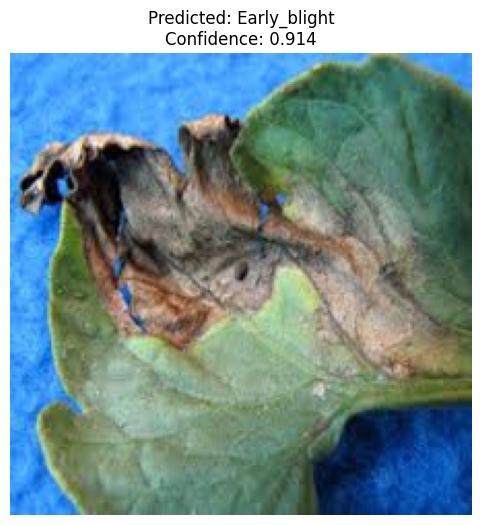

In [118]:

# === Usage Examples ===

# Single image prediction
image_path =   "/Users/abdulmateen/Downloads/late_blight_sample.jpeg"
visualize_prediction(image_path, model)

# Multiple images prediction
# image_paths = [
#     "/path/to/image1.jpg",
#     "/path/to/image2.jpg",
#     "/path/to/image3.jpg"
# ]
# predict_multiple_images(image_paths, model)

# If you want to predict images from a directory
# import glob
# image_directory = "/path/to/your/images/"
# image_paths = glob.glob(os.path.join(image_directory, "*.jpg"))  # Adjust extension as needed
# predict_multiple_images(image_paths, model)


🖼️ Test Image Index: 1012
Bacterial_spot: 1.0000
Early_blight: 0.0000
Late_Blight: 0.0000
➡️ Predicted: Bacterial_spot (confidence: 1.000)
✅ Actual: Bacterial_spot


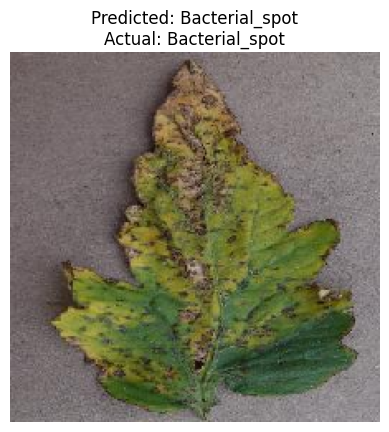


🖼️ Test Image Index: 801
Bacterial_spot: 0.0000
Early_blight: 0.0000
Late_Blight: 1.0000
➡️ Predicted: Late_Blight (confidence: 1.000)
✅ Actual: Late_Blight


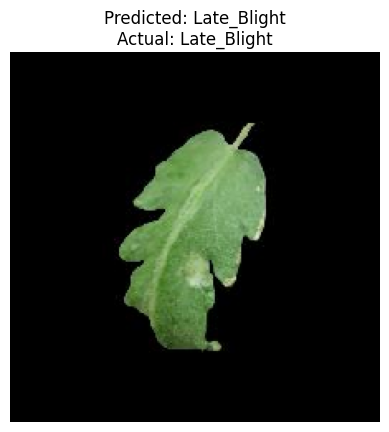


🖼️ Test Image Index: 2468
Bacterial_spot: 1.0000
Early_blight: 0.0000
Late_Blight: 0.0000
➡️ Predicted: Bacterial_spot (confidence: 1.000)
✅ Actual: Bacterial_spot


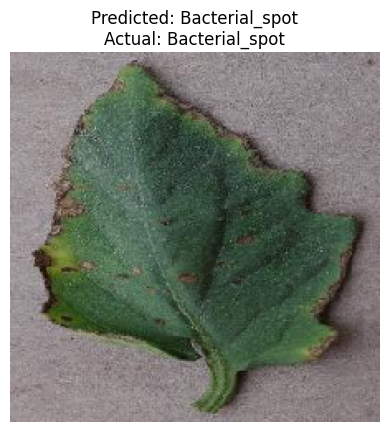


🖼️ Test Image Index: 2786
Bacterial_spot: 0.0000
Early_blight: 0.0000
Late_Blight: 1.0000
➡️ Predicted: Late_Blight (confidence: 1.000)
✅ Actual: Late_Blight


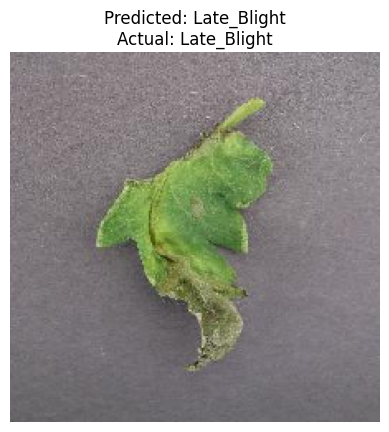


🖼️ Test Image Index: 473
Bacterial_spot: 1.0000
Early_blight: 0.0000
Late_Blight: 0.0000
➡️ Predicted: Bacterial_spot (confidence: 1.000)
✅ Actual: Bacterial_spot


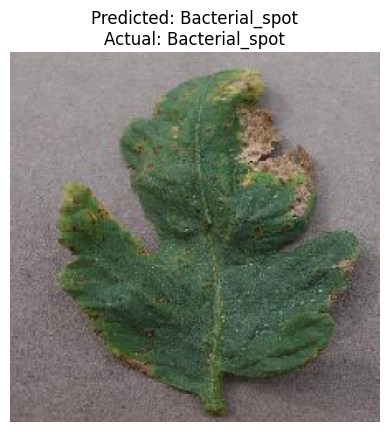

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# === Your class index-to-name mapping ===
class_names = {
    0: "Bacterial_spot",
    1: "Early_blight",
    2: "Late_Blight"
}

# === Predict and visualize a few test images ===
num_samples = 5  # or however many you want to inspect

indices = np.random.choice(len(train_images), num_samples, replace=False)

for idx in indices:
    img = train_images[idx]
    label = train_labels[idx]

    # Expand dims for prediction
    img_input = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img_input, verbose=0)[0]
    predicted_class = np.argmax(prediction)

    # Print probabilities
    print(f"\n🖼️ Test Image Index: {idx}")
    for i, prob in enumerate(prediction):
        print(f"{class_names[i]}: {prob:.4f}")
    print(f"➡️ Predicted: {class_names[predicted_class]} (confidence: {prediction[predicted_class]:.3f})")
    print(f"✅ Actual: {class_names[label]}")

    # Display the image
    plt.imshow(img.astype("uint8"))
    plt.title(f"Predicted: {class_names[predicted_class]}\nActual: {class_names[label]}")
    plt.axis('off')
    plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step


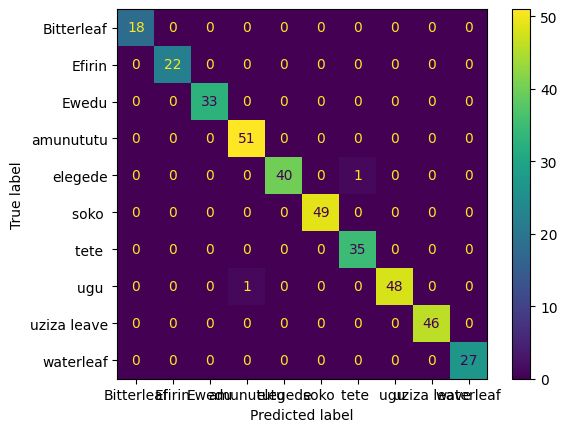

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(test_images), axis=1)
ConfusionMatrixDisplay.from_predictions(test_labels, y_pred, display_labels=class_names)


In [26]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Mean Test Loss: {loss:.4f}")
print(f"Mean Test Accuracy: {accuracy:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 1.0000 - loss: 0.0036
Mean Test Loss: 0.0044
Mean Test Accuracy: 1.0000


In [23]:
#!/usr/bin/env python3
"""
Evaluation Metrics for Classification Models
Calculate F1 score and R² score for model evaluation
"""

import numpy as np
from sklearn.metrics import f1_score, r2_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def calculate_metrics(y_true, y_pred, class_names=None):
    """
    Calculate F1 score and R² score for classification
    
    Args:
        y_true (array): True labels
        y_pred (array): Predicted labels
        class_names (list): Names of classes (optional)
        
    Returns:
        dict: Dictionary containing metrics
    """
    # Convert to numpy arrays if needed
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate F1 score (macro average for multi-class)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate R² score
    r2 = r2_score(y_true, y_pred)
    
    # Calculate per-class F1 scores
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    # Calculate accuracy
    accuracy = np.mean(y_true == y_pred)
    
    # Create results dictionary
    results = {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'f1_weighted': f1_weighted,
        'f1_per_class': f1_per_class,
        'r2_score': r2,
        'accuracy': accuracy,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    return results

calculate_metrics(test_labels, y_pred)


{'f1_macro': 0.9953551797730806,
 'f1_micro': 0.9946091644204852,
 'f1_weighted': 0.9946106985007324,
 'f1_per_class': array([1.        , 1.        , 1.        , 0.99029126, 0.98765432,
        1.        , 0.98591549, 0.98969072, 1.        , 1.        ]),
 'r2_score': 0.9917234609764531,
 'accuracy': 0.9946091644204852,
 'y_true': array([2, 3, 6, 8, 3, 7, 8, 6, 6, 7, 9, 5, 7, 6, 5, 8, 5, 2, 5, 7, 4, 4,
        1, 5, 3, 7, 3, 3, 8, 8, 8, 9, 5, 6, 7, 5, 9, 9, 6, 2, 3, 1, 3, 3,
        7, 2, 9, 1, 6, 3, 8, 7, 7, 3, 6, 8, 6, 8, 5, 0, 7, 2, 4, 2, 2, 1,
        5, 0, 5, 7, 4, 2, 4, 4, 5, 1, 4, 8, 9, 3, 6, 4, 5, 8, 3, 7, 2, 4,
        7, 3, 4, 4, 5, 7, 4, 5, 1, 2, 1, 5, 2, 7, 9, 7, 5, 7, 5, 7, 4, 6,
        5, 4, 4, 9, 4, 8, 3, 7, 7, 8, 8, 7, 3, 5, 4, 2, 0, 3, 9, 4, 2, 4,
        6, 8, 8, 4, 1, 8, 5, 8, 0, 7, 0, 3, 6, 8, 6, 8, 2, 5, 9, 7, 2, 9,
        6, 6, 6, 9, 3, 6, 3, 5, 1, 3, 5, 5, 6, 8, 7, 4, 4, 3, 4, 8, 3, 2,
        8, 3, 4, 0, 9, 5, 6, 1, 5, 1, 3, 4, 3, 0, 4, 5, 2, 4, 6, 8, 7, 7,
  

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import tensorflow as tf

# === Class index-to-name mapping ===
class_names = {
    0: "Bacterial_spot",
    1: "Early_blight",
    2: "Late_Blight"
}

def predict_image_from_path_tflite(image_path, interpreter, target_size=(224, 224)):
    """
    Predict image using TFLite quantized model
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")
    
    # Load and preprocess image
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size)
    
    # Keep original image for display (0-255 range)
    img_display = np.array(img)
    
    # Prepare image for model input
    img_array = np.array(img).astype(np.float32)
    
    # Get quantization info
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # Check if the model expects quantized input
    if input_details[0]['dtype'] == np.uint8:
        # For quantized input (uint8)
        scale, zero_point = input_details[0]['quantization']
        
        # Normalize to [0, 1] first
        img_normalized = img_array / 255.0
        
        # Apply quantization
        img_quantized = img_normalized / scale + zero_point
        img_input = np.expand_dims(img_quantized, axis=0).astype(np.uint8)
    else:
        # For float32 input
        img_normalized = img_array / 255.0
        img_input = np.expand_dims(img_normalized, axis=0).astype(np.float32)
    
    # Run inference
    interpreter.set_tensor(input_details[0]['index'], img_input)
    interpreter.invoke()
    
    # Get prediction
    prediction = interpreter.get_tensor(output_details[0]['index'])[0]
    
    # Handle quantized output
    if output_details[0]['dtype'] == np.uint8:
        scale, zero_point = output_details[0]['quantization']
        prediction = scale * (prediction.astype(np.float32) - zero_point)
    
    # Apply softmax if needed (quantized models might not have softmax in the output)
    if not np.allclose(np.sum(prediction), 1.0, atol=0.1):
        prediction = tf.nn.softmax(prediction).numpy()
    
    predicted_class = np.argmax(prediction)
    
    return img_display, prediction, predicted_class

def visualize_prediction_tflite(image_path, interpreter, target_size=(224, 224)):
    """
    Predict and visualize a single image using TFLite model
    """
    try:
        img_display, prediction, predicted_class = predict_image_from_path_tflite(
            image_path, interpreter, target_size
        )
        
        print(f"\n🖼️ Image: {os.path.basename(image_path)}")
        print(f"📁 Path: {image_path}")
        for i, prob in enumerate(prediction):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"➡️ Predicted: {class_names[predicted_class]} (confidence: {prediction[predicted_class]:.3f})")
        
        # Display the original image (not the quantized version)
        plt.figure(figsize=(8, 6))
        plt.imshow(img_display.astype("uint8"))
        plt.title(f"Predicted: {class_names[predicted_class]}\nConfidence: {prediction[predicted_class]:.3f}")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing image {image_path}: {str(e)}")

def predict_multiple_images_tflite(image_paths, model_path="model_quantized1.tflite", target_size=(224, 224)):
    """
    Predict and visualize multiple images from filepaths using a TFLite model
    """
    try:
        interpreter = tf.lite.Interpreter(model_path=model_path)
        interpreter.allocate_tensors()
        
        # Print model info for debugging
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        
        print(f"Model loaded: {model_path}")
        print(f"Input shape: {input_details[0]['shape']}")
        print(f"Input dtype: {input_details[0]['dtype']}")
        print(f"Output shape: {output_details[0]['shape']}")
        print(f"Output dtype: {output_details[0]['dtype']}")
        
        for image_path in image_paths:
            visualize_prediction_tflite(image_path, interpreter, target_size)
            
    except Exception as e:
        print(f"Error loading model or processing images: {str(e)}")



Model loaded: model_quantized1.tflite
Input shape: [  1 224 224   3]
Input dtype: <class 'numpy.uint8'>
Output shape: [1 3]
Output dtype: <class 'numpy.uint8'>

🖼️ Image: image (266).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (266).JPG
Bacterial_spot: 0.4102
Early_blight: 0.0000
Late_Blight: 0.5898
➡️ Predicted: Late_Blight (confidence: 0.590)


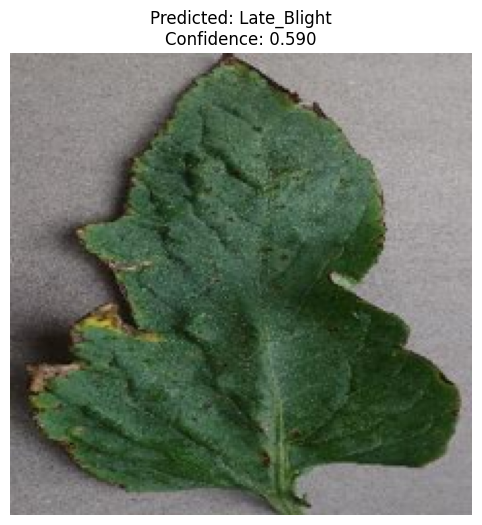


🖼️ Image: image (265).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (265).JPG
Bacterial_spot: 0.4766
Early_blight: 0.0000
Late_Blight: 0.5234
➡️ Predicted: Late_Blight (confidence: 0.523)


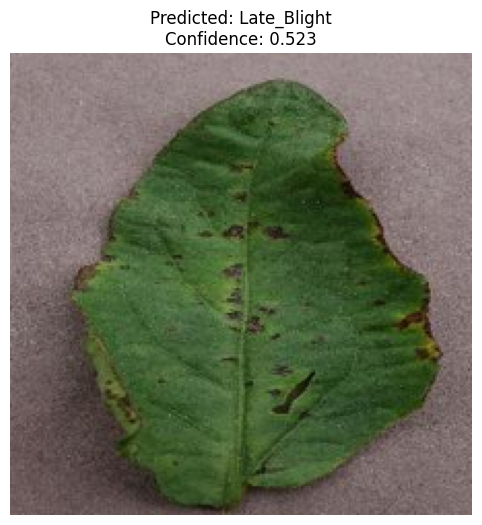


🖼️ Image: image (62).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (62).JPG
Bacterial_spot: 0.5156
Early_blight: 0.0000
Late_Blight: 0.4844
➡️ Predicted: Bacterial_spot (confidence: 0.516)


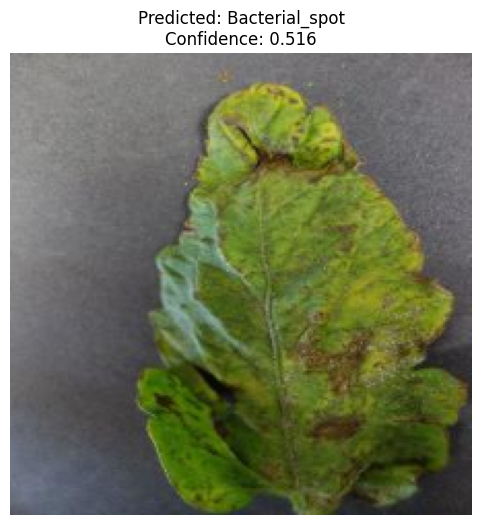


🖼️ Image: image (30).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Late_blight/image (30).JPG
Bacterial_spot: 0.4023
Early_blight: 0.0000
Late_Blight: 0.5977
➡️ Predicted: Late_Blight (confidence: 0.598)


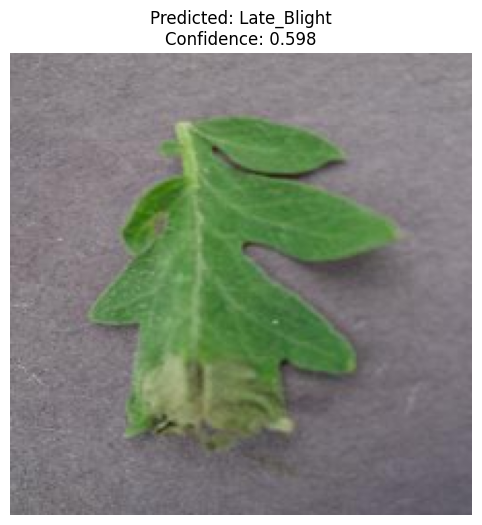


🖼️ Image: image (3).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Late_blight/image (3).JPG
Bacterial_spot: 0.5977
Early_blight: 0.0000
Late_Blight: 0.4023
➡️ Predicted: Bacterial_spot (confidence: 0.598)


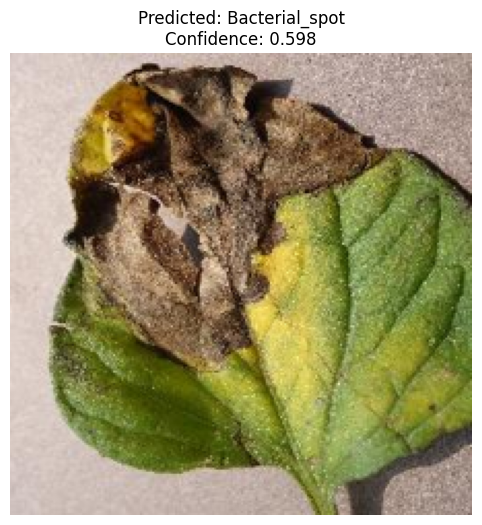


🖼️ Image: image (300).JPG
📁 Path: /Users/abdulmateen/Downloads/tomato/Late_blight/image (300).JPG
Bacterial_spot: 0.4844
Early_blight: 0.0000
Late_Blight: 0.5156
➡️ Predicted: Late_Blight (confidence: 0.516)


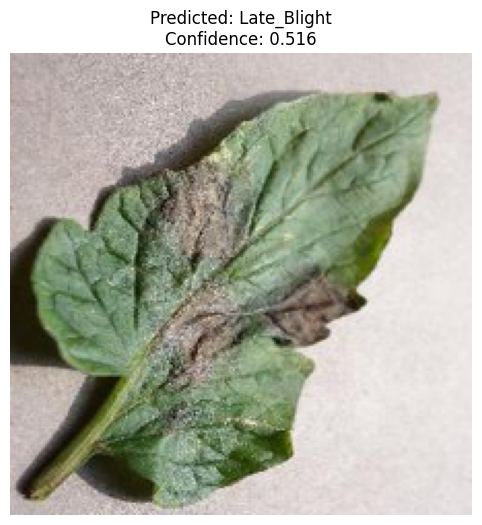

In [103]:
# === Usage Examples ===

# Test with a few sample images
sample_images = [
    '/Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (266).JPG',
    '/Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (265).JPG',
    '/Users/abdulmateen/Downloads/tomato/Bacterial_spot/image (62).JPG',
    '/Users/abdulmateen/Downloads/tomato/Late_blight/image (30).JPG',
    '/Users/abdulmateen/Downloads/tomato/Late_blight/image (3).JPG',
    '/Users/abdulmateen/Downloads/tomato/Late_blight/image (300).JPG'
]
predict_multiple_images_tflite(sample_images)

# Or use your existing sample paths
# predict_multiple_images_tflite(sample_image_paths[:5])  # Test with first 5 images

In [90]:
def create_float16_model():
    """Float16 quantization - good balance between size and accuracy"""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    
    tflite_model = converter.convert()
    
    with open('model_float16.tflite', 'wb') as f:
        f.write(tflite_model)
    print("✅ Float16 model saved as 'model_float16.tflite'")
    return tflite_model

In [92]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


In [ ]:
#!/usr/bin/env python3
"""
Model Quantization Script
Automatically quantizes your segmentation model using the structured dataset
"""

import tensorflow as tf
import numpy as np
import os
import argparse
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from tensorflow.lite.python.interpreter import Interpreter

# Add HEIC support
try:
    from PIL import Image
    import pillow_heif
    HEIC_SUPPORT = True
except ImportError:
    print("⚠️ HEIC support not available. Install with: pip install pillow-heif")
    HEIC_SUPPORT = False


def load_heic_image(image_path):
    """
    Load HEIC image and convert to RGB numpy array
    
    Args:
        image_path (str): Path to HEIC image
        
    Returns:
        numpy.ndarray: RGB image array
    """
    if not HEIC_SUPPORT:
        raise ImportError("HEIC support not available. Install pillow-heif")
    
    try:
        # Register HEIF opener with Pillow
        pillow_heif.register_heif_opener()
        
        # Open HEIC image
        with Image.open(image_path) as img:
            # Convert to RGB if needed
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # Convert to numpy array
            img_array = np.array(img)
            
            return img_array
            
    except Exception as e:
        raise Exception(f"Error loading HEIC image {image_path}: {str(e)}")


def load_image(image_path):
    """
    Load image in any supported format (PNG, JPG, HEIC)
    
    Args:
        image_path (str): Path to image file
        
    Returns:
        numpy.ndarray: RGB image array
    """
    # Check file extension
    file_ext = os.path.splitext(image_path)[1].lower()
    
    if file_ext in ['.heic', '.heif']:
        # Load HEIC image
        return load_heic_image(image_path)
    else:
        # Load standard image formats using TensorFlow
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        return img.numpy()


def create_representative_dataset(data_directory, num_samples=100):
    """
    Create representative dataset from structured folder with class subfolders
    
    Args:
        data_directory (str): Root directory containing class subfolders
        num_samples (int): Number of samples to use for calibration
    
    Returns:
        function: Representative dataset generator
    """
    print(f"🔄 Creating representative dataset from {data_directory}...")
    
    # Find all image files in subdirectories (including HEIC)
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.heic', '*.heif']
    image_files = []
    
    for ext in image_extensions:
        pattern = os.path.join(data_directory, '**', ext)
        image_files.extend(glob.glob(pattern, recursive=True))
        pattern = os.path.join(data_directory, '**', ext.upper())
        image_files.extend(glob.glob(pattern, recursive=True))
    
    print(f"📊 Found {len(image_files)} total images in structured dataset")
    
    # Limit to num_samples
    if len(image_files) > num_samples:
        # Sample evenly from different classes
        class_files = {}
        for img_path in image_files:
            class_name = os.path.basename(os.path.dirname(img_path))
            if class_name not in class_files:
                class_files[class_name] = []
            class_files[class_name].append(img_path)
        
        # Sample evenly from each class
        samples_per_class = max(1, num_samples // len(class_files))
        selected_files = []
        
        for class_name, files in class_files.items():
            if len(files) <= samples_per_class:
                selected_files.extend(files)
            else:
                # Randomly sample from this class
                indices = np.random.choice(len(files), samples_per_class, 
                                         replace=False)
                selected_files.extend([files[i] for i in indices])
        
        # If we still need more samples, add randomly
        if len(selected_files) < num_samples:
            remaining_needed = num_samples - len(selected_files)
            remaining_files = [f for f in image_files if f not in selected_files]
            if remaining_files:
                additional_samples = np.random.choice(
                    remaining_files, 
                    min(remaining_needed, len(remaining_files)), 
                    replace=False
                )
                selected_files.extend(additional_samples)
        
        image_files = selected_files[:num_samples]
    
    print(f"📊 Using {len(image_files)} images for calibration")
    
    def representative_dataset():
        """Generate representative dataset for quantization"""
        for i, image_path in enumerate(image_files):
            try:
                # Load image (supports HEIC and standard formats)
                img_array = load_image(image_path)
                
                # Convert to tensor and preprocess
                img = tf.convert_to_tensor(img_array, dtype=tf.float32)
                img = tf.image.resize(img, (96, 128), method='nearest')
                
                # Add batch dimension
                img = tf.expand_dims(img, axis=0)
                
                yield [img]
                
            except Exception as e:
                print(f"⚠️ Error processing {image_path}: {str(e)}")
                continue
    
    return representative_dataset


def create_float16_quantized_model(model_path, output_path="model_float16.tflite"):
    """Convert Keras model to Float16 quantized TFLite model"""
    print("🔄 Converting to Float16 quantized model...")
    
    model = tf.keras.models.load_model(model_path)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    
    tflite_model = converter.convert()
    
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    
    original_size = os.path.getsize(model_path) / 1024 / 1024
    quantized_size = len(tflite_model) / 1024 / 1024
    compression_ratio = original_size / quantized_size
    
    print(f"📊 Original: {original_size:.2f} MB")
    print(f"📊 Quantized: {quantized_size:.2f} MB")
    print(f"📊 Compression: {compression_ratio:.2f}x")
    print(f"✅ Saved as '{output_path}'")
    
    return output_path


def create_int8_quantized_model(model_path, representative_dataset, 
                               output_path="model_int8.tflite"):
    """Convert Keras model to INT8 quantized TFLite model"""
    print("🔄 Converting to INT8 quantized model...")
    
    model = tf.keras.models.load_model(model_path)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.uint8
    
    tflite_model = converter.convert()
    
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    
    original_size = os.path.getsize(model_path) / 1024 / 1024
    quantized_size = len(tflite_model) / 1024 / 1024
    compression_ratio = original_size / quantized_size
    
    print(f"📊 Original: {original_size:.2f} MB")
    print(f"📊 Quantized: {quantized_size:.2f} MB")
    print(f"📊 Compression: {compression_ratio:.2f}x")
    print(f"✅ Saved as '{output_path}'")
    
    return output_path


def create_dynamic_quantized_model(model_path, output_path="model_dynamic.tflite"):
    """Convert Keras model to dynamically quantized TFLite model"""
    print("🔄 Converting to dynamic quantized model...")
    
    model = tf.keras.models.load_model(model_path)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    tflite_model = converter.convert()
    
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    
    original_size = os.path.getsize(model_path) / 1024 / 1024
    quantized_size = len(tflite_model) / 1024 / 1024
    compression_ratio = original_size / quantized_size
    
    print(f"📊 Original: {original_size:.2f} MB")
    print(f"📊 Quantized: {quantized_size:.2f} MB")
    print(f"📊 Compression: {compression_ratio:.2f}x")
    print(f"✅ Saved as '{output_path}'")
    
    return output_path


def test_quantized_model(model_path, test_image_path):
    """Test a quantized model with a sample image"""
    print(f"🧪 Testing model: {model_path}")
    
    try:
        interpreter = Interpreter(model_path=model_path)
        interpreter.allocate_tensors()
        
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        
        # Load and preprocess test image (supports HEIC)
        img_array = load_image(test_image_path)
        img = tf.convert_to_tensor(img_array, dtype=tf.float32)
        img = tf.image.resize(img, (96, 128), method='nearest')
        
        # Prepare input based on model type
        if input_details[0]['dtype'] == np.uint8:
            # Quantized input
            scale, zero_point = input_details[0]['quantization']
            img_normalized = img.numpy()
            img_quantized = img_normalized / scale + zero_point
            input_data = np.expand_dims(img_quantized, axis=0).astype(np.uint8)
        else:
            # Float input
            input_data = np.expand_dims(img.numpy(), axis=0).astype(np.float32)
        
        # Run inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        
        # Get output
        output_data = interpreter.get_tensor(output_details[0]['index'])
        model_size = os.path.getsize(model_path) / 1024 / 1024
        
        print(f"✅ Model size: {model_size:.2f} MB")
        print(f"✅ Output shape: {output_data.shape}")
        print(f"✅ Output dtype: {output_data.dtype}")
        
        return {
            'size_mb': model_size,
            'output_shape': output_data.shape,
            'output_dtype': str(output_data.dtype),
            'status': 'success'
        }
        
    except Exception as e:
        print(f"❌ Error testing model: {str(e)}")
        return {'status': 'error', 'error': str(e)}


def create_all_quantized_models(model_path, data_directory, output_dir="quantized_models", 
                               num_samples=100):
    """
    Create all types of quantized models
    
    Args:
        model_path (str): Path to the original .h5 model
        data_directory (str): Directory containing structured dataset
        output_dir (str): Directory to save quantized models
        num_samples (int): Number of samples for calibration
    """
    print("🚀 Starting model quantization process...")
    print(f"📁 Model: {model_path}")
    print(f"📁 Dataset: {data_directory}")
    print(f"📁 Output: {output_dir}")
    print(f"📊 Calibration samples: {num_samples}")
    
    if HEIC_SUPPORT:
        print("✅ HEIC format support enabled")
    else:
        print("⚠️ HEIC format support not available")
    
    # Check if model exists
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        return
    
    # Check if dataset exists
    if not os.path.exists(data_directory):
        print(f"❌ Dataset directory not found: {data_directory}")
        return
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Create representative dataset
    representative_dataset = create_representative_dataset(data_directory, num_samples)
    
    model_paths = {}
    results = {}
    
    # 1. Float16 quantization
    try:
        float16_path = os.path.join(output_dir, "model_float16.tflite")
        model_paths['Float16'] = create_float16_quantized_model(model_path, float16_path)
        
        # Find a test image (any format)
        test_images = list(Path(data_directory).rglob("*.png")) + \
                     list(Path(data_directory).rglob("*.jpg")) + \
                     list(Path(data_directory).rglob("*.heic"))
        
        if test_images:
            results['Float16'] = test_quantized_model(float16_path, str(test_images[0]))
    except Exception as e:
        print(f"❌ Float16 quantization failed: {str(e)}")
    
    # 2. Dynamic quantization
    try:
        dynamic_path = os.path.join(output_dir, "model_dynamic.tflite")
        model_paths['Dynamic'] = create_dynamic_quantized_model(model_path, dynamic_path)
        
        if test_images:
            results['Dynamic'] = test_quantized_model(dynamic_path, str(test_images[0]))
    except Exception as e:
        print(f"❌ Dynamic quantization failed: {str(e)}")
    
    # 3. INT8 quantization with representative dataset
    try:
        int8_path = os.path.join(output_dir, "model_int8.tflite")
        model_paths['INT8'] = create_int8_quantized_model(
            model_path, representative_dataset, int8_path
        )
        
        if test_images:
            results['INT8'] = test_quantized_model(int8_path, str(test_images[0]))
    except Exception as e:
        print(f"❌ INT8 quantization failed: {str(e)}")
    
    # Print summary
    print("\n" + "="*50)
    print("📊 QUANTIZATION SUMMARY")
    print("="*50)
    
    original_size = os.path.getsize(model_path) / 1024 / 1024
    print(f"📊 Original model size: {original_size:.2f} MB")
    
    for model_name, result in results.items():
        if result.get('status') == 'success':
            size = result['size_mb']
            compression = original_size / size
            print(f"✅ {model_name}: {size:.2f} MB ({compression:.1f}x compression)")
        else:
            print(f"❌ {model_name}: Failed")
    
    print(f"\n✅ Quantized models saved in: {output_dir}")
    return model_paths, results


def main():
    parser = argparse.ArgumentParser(description='Quantize TensorFlow model')
    parser.add_argument('--model', required=True, help='Path to the .h5 model file')
    parser.add_argument('--dataset', required=True, help='Path to dataset directory')
    parser.add_argument('--output', default='quantized_models', help='Output directory')
    parser.add_argument('--samples', type=int, default=100, help='Number of calibration samples')
    
    args = parser.parse_args()
    
    print("🎯 Model Quantization Tool")
    print("="*40)
    
    # Create all quantized models
    model_paths, results = create_all_quantized_models(
        model_path=args.model,
        data_directory=args.dataset,
        output_dir=args.output,
        num_samples=args.samples
    )
    
    print("\n🎉 Quantization completed!")
    print(f"📁 Check the '{args.output}' directory for quantized models")

python quantize_model.py --model notebook/faruq.h5 --dataset "/Users/abdulmateen/Downloads/veggie"
if __name__ == "__main__":
    main() 